In [2]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

In [3]:
# data is taken from 2023 - current date 
# load the aemo data
files = sorted(glob.glob("aemo/*.csv"))
 
aemo_list = []
for f in files:
    aemo_list.append(pd.read_csv(f))
    # one csv per month, concat all together
aemo = pd.concat(aemo_list, ignore_index=True)
 
aemo["SETTLEMENTDATE"] = pd.to_datetime(aemo["SETTLEMENTDATE"])
print("no of rows:", len(aemo))
print(aemo.head())
print(aemo.info())

no of rows: 379584
  REGION      SETTLEMENTDATE  TOTALDEMAND     RRP PERIODTYPE
0   VIC1 2023-01-01 00:05:00      4676.57  129.51      TRADE
1   VIC1 2023-01-01 00:10:00      4722.43  124.72      TRADE
2   VIC1 2023-01-01 00:15:00      4672.63  111.64      TRADE
3   VIC1 2023-01-01 00:20:00      4616.49  110.75      TRADE
4   VIC1 2023-01-01 00:25:00      4604.27  110.91      TRADE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 379584 entries, 0 to 379583
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   REGION          379584 non-null  object        
 1   SETTLEMENTDATE  379584 non-null  datetime64[ns]
 2   TOTALDEMAND     379584 non-null  float64       
 3   RRP             379584 non-null  float64       
 4   PERIODTYPE      379584 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 14.5+ MB
None


In [4]:
# this is done to count the time 00:00 as the previos day 
aemo["interval_start"] = aemo["SETTLEMENTDATE"] - pd.Timedelta(minutes=5)
aemo["date"] = aemo["interval_start"].dt.normalize()
 
daily = aemo.groupby("date").agg(
    demand_mean=("TOTALDEMAND", "mean"),
    demand_max=("TOTALDEMAND", "max"),
    rrp_mean=("RRP", "mean"),
    rrp_max=("RRP", "max")
).reset_index()
print(daily.head())

        date  demand_mean  demand_max   rrp_mean  rrp_max
0 2023-01-01  5011.300035     7514.88  58.101111   185.86
1 2023-01-02  4726.902361     5669.79  46.006840   134.15
2 2023-01-03  4092.645521     4912.80  14.314132   101.90
3 2023-01-04  4048.985000     4852.47 -26.599826    34.95
4 2023-01-05  3885.699896     4729.38 -16.955521    19.19


In [5]:
# load BOM data

tmax = pd.read_csv("bom/max_temp.csv")
tmin = pd.read_csv("bom/min_temp.csv")
rain = pd.read_csv("bom/rainfall.csv")
solar = pd.read_csv("bom/solar_exposure.csv")
 
 
# combine into a single date
def make_date(d):
    return pd.to_datetime(dict(year=d["Year"], month=d["Month"], day=d["Day"]))
 
tmax["date"] = make_date(tmax)
tmin["date"] = make_date(tmin)
rain["date"] = make_date(rain)
solar["date"] = make_date(solar)
 
tmax = tmax[["date", "Maximum temperature (Degree C)"]]
tmax.columns = ["date", "tmax"]
 
tmin = tmin[["date", "Minimum temperature (Degree C)"]]
tmin.columns = ["date", "tmin"]
 
rain = rain[["date", "Rainfall amount (millimetres)"]]
rain.columns = ["date", "rain"]
 
solar = solar[["date", "Daily global solar exposure (MJ/m*m)"]]
solar.columns = ["date", "solar"]

weather = tmax.merge(tmin, on="date").merge(rain, on="date").merge(solar, on="date")
print(weather.tail())


           date  tmax  tmin  rain  solar
4965 2026-08-06  16.8   8.1   7.2    9.2
4966 2026-08-07  16.0  10.3   0.2   10.0
4967 2026-08-08  17.7   9.8   0.0   11.1
4968 2026-08-09  14.3  11.5   1.4    3.9
4969 2026-08-10  13.1  10.1  24.4    5.3


In [6]:
# merge the two datasets together
df = daily.merge(weather, on="date", how="left")
df = df.sort_values("date").reset_index(drop=True)

# check missing values
print(df.isnull().sum())

# only tmax and solar contain missing values, we can interpolate them
df["tmax"] = df["tmax"].interpolate()
df["solar"] = df["solar"].interpolate()

print(df.isnull().sum())


date           0
demand_mean    0
demand_max     0
rrp_mean       0
rrp_max        0
tmax           3
tmin           0
rain           0
solar          1
dtype: int64
date           0
demand_mean    0
demand_max     0
rrp_mean       0
rrp_max        0
tmax           0
tmin           0
rain           0
solar          0
dtype: int64


In [7]:
# adding features
df["temp_mean"] = (df["tmax"] + df["tmin"]) / 2
df["temp_range"] = df["tmax"] - df["tmin"]
df["cdd"] = (df["temp_mean"] - 18).clip(lower=0)   # cooling degree days
df["hdd"] = (18 - df["temp_mean"]).clip(lower=0)   # heating degree days
df["dayofweek"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# target is top 10% of busiest days
threshold = df["demand_max"].quantile(0.90)
df["is_peak"] = (df["demand_max"] >= threshold).astype(int)
df["demand_lag1"] = df["demand_max"].shift(1)    # yesterday
df["demand_lag7"] = df["demand_max"].shift(7)    # same day last week
df["rrp_lag1"] = df["rrp_mean"].shift(1)    

df = df.dropna(subset=["demand_lag1", "demand_lag7", "rrp_lag1"])
df = df.reset_index(drop=True)

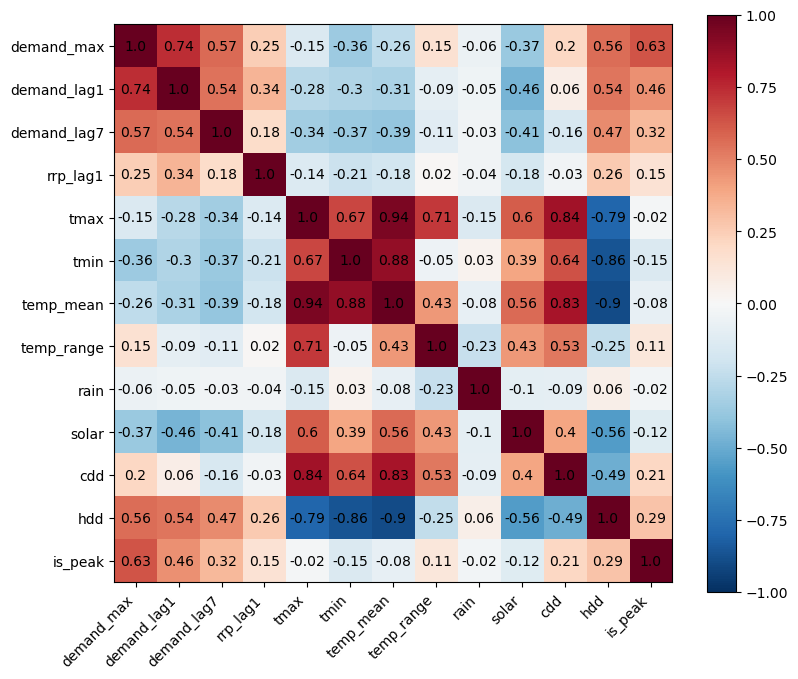

In [8]:
cols = ["demand_max", "demand_lag1", "demand_lag7", "rrp_lag1",
        "tmax", "tmin", "temp_mean", "temp_range", "rain", "solar",
        "cdd", "hdd", "is_peak"]

corr = df[cols].corr()

plt.figure(figsize=(9, 7.5))
plt.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
plt.yticks(range(len(cols)), cols)

# write the number inside each square
for a in range(len(cols)):
    for b in range(len(cols)):
        plt.text(b, a, round(corr.iloc[a, b], 2), ha="center", va="center")

plt.colorbar()



In [9]:
# peak months
df.groupby([df['month']]).agg({'is_peak': 'sum'})

,is_peak
month,
1,10
2,18
3,7
4,0
5,2
6,32
7,50
8,11
9,0


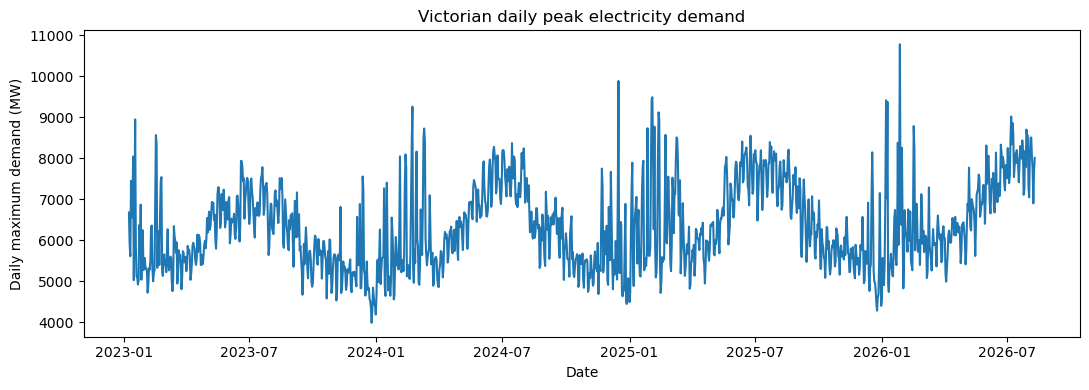

In [10]:
#demand over time
plt.figure(figsize=(11, 4))
plt.plot(df["date"], df["demand_max"])
plt.xlabel("Date")
plt.ylabel("Daily maximum demand (MW)")
plt.title("Victorian daily peak electricity demand")
plt.tight_layout()

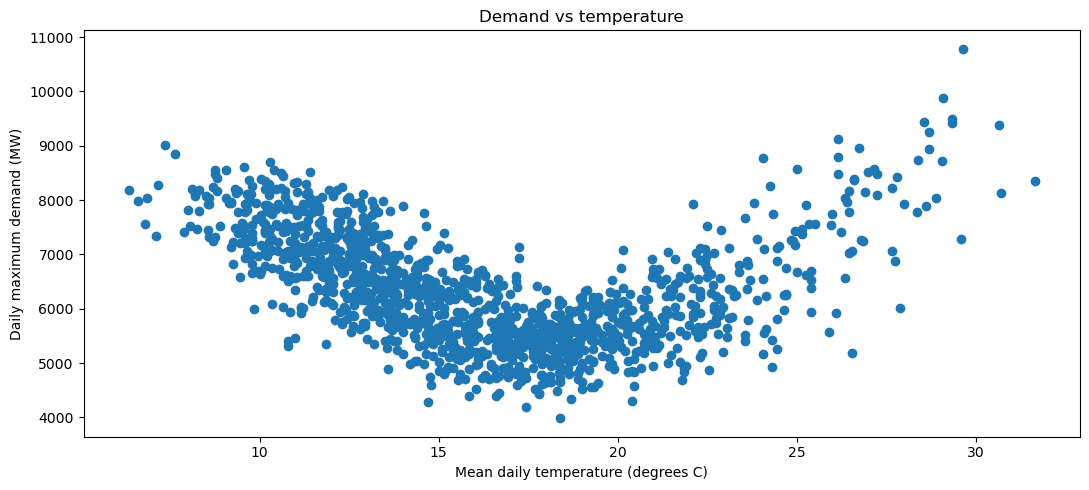

In [11]:
#demand vs temperature
plt.figure(figsize=(11, 5))
plt.scatter(df["temp_mean"], df["demand_max"])
plt.xlabel("Mean daily temperature (degrees C)")
plt.ylabel("Daily maximum demand (MW)")
plt.title("Demand vs temperature")
plt.tight_layout()


In [12]:
aemo_cols  = ["demand_lag1", "demand_lag7", "rrp_lag1","dayofweek","month","is_weekend"]
weather_cols = ["tmax","tmin","temp_mean","temp_range","rain","solar","cdd","hdd"]
 
feature_sets = {
    "AEMO columns": aemo_cols ,
    "Weather columns": weather_cols,
    "Combined": aemo_cols  + weather_cols
}

y = df["is_peak"].values

# for training, using first 75% of the data, so that it doesnt use future data to predict
split = int(len(df) * 0.75)
y_train, y_test = y[:split], y[split:]



In [13]:
results = []
for i, j in feature_sets.items():

    X = df[j].values
    X_train = X[:split]
    X_test = X[split:]

    # scale the features 
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # odel 1: Logistic Regression
    # class_weight="balanced" because only 10% of days are peaks.

    lr = LogisticRegression(max_iter=2000, class_weight="balanced",random_state=42)
    lr.fit(X_train_s, y_train)
    lr_pred = lr.predict(X_test_s)
    lr_prob = lr.predict_proba(X_test_s)[:, 1]

    results.append({
        "Model": "Logistic Regression",
        "Features": i,
        "Accuracy": accuracy_score(y_test, lr_pred),
        "Precision": precision_score(y_test, lr_pred),
        "Recall": recall_score(y_test, lr_pred),
        "F1": f1_score(y_test, lr_pred),
        "ROC-AUC": roc_auc_score(y_test, lr_prob),
        "PR-AUC": average_precision_score(y_test, lr_prob)
    })

    # Model 2: XGBoost
    # scale_pos_weight does the same job as class_weight="balanced".

    n_neg = (y_train == 0).sum()
    n_pos = (y_train == 1).sum()

    xgb = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,scale_pos_weight=n_neg / n_pos,
                        eval_metric="logloss", random_state=42)
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_prob = xgb.predict_proba(X_test)[:, 1]

    results.append({
        "Model": "XGBoost",
        "Features": i,
        "Accuracy": accuracy_score(y_test, xgb_pred),
        "Precision": precision_score(y_test, xgb_pred),
        "Recall": recall_score(y_test, xgb_pred),
        "F1": f1_score(y_test, xgb_pred),
        "ROC-AUC": roc_auc_score(y_test, xgb_prob),
        "PR-AUC": average_precision_score(y_test, xgb_prob)
    })



                 Model         Features  Accuracy  Precision  Recall     F1  \
0  Logistic Regression     AEMO columns     0.823      0.419   0.907  0.574   
1              XGBoost     AEMO columns     0.921      0.689   0.721  0.705   
2  Logistic Regression  Weather columns     0.905      0.630   0.674  0.652   
3              XGBoost  Weather columns     0.896      0.667   0.419  0.514   
4  Logistic Regression         Combined     0.915      0.627   0.860  0.725   
5              XGBoost         Combined     0.942      0.900   0.628  0.740   

   ROC-AUC  PR-AUC  
0    0.912   0.510  
1    0.952   0.745  
2    0.936   0.652  
3    0.906   0.657  
4    0.967   0.779  
5    0.989   0.929  


Text(0, 0.5, 'F1 score')

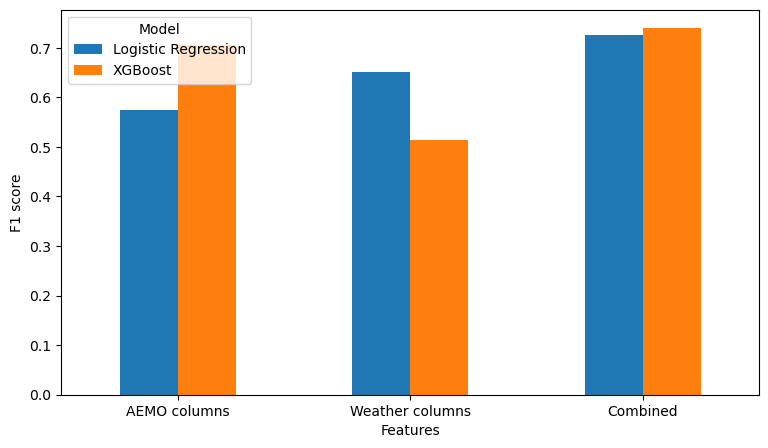

In [14]:
results_df = pd.DataFrame(results)

print(results_df.round(3))

plt.figure(figsize=(9, 5))
pivot = results_df.pivot(index="Features", columns="Model", values="F1")
pivot = pivot.reindex(list(feature_sets.keys()))
pivot.plot(kind="bar", rot=0, ax=plt.gca())
plt.ylabel("F1 score")



In [15]:
random = np.zeros(len(y_test))
print("Baseline")
print("Accuracy:", round(accuracy_score(y_test, random), 3))
print("Recall:  ", round(recall_score(y_test, random, zero_division=0), 3))

Baseline
Accuracy: 0.869
Recall:   0.0


In [16]:
tn, fp, fn, tp = confusion_matrix(y_test, lr_pred).ravel()
print("Logistic Regression (combined features)")
print("Peaks correctly predicted:", tp)
print("Peaks missed:", fn)
print("False alarms:", fp)
print("Quiet days correct:", tn)

tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred).ravel()
print("XGBoost (combined features)")
print("Peaks correctly predicted:", tp)
print("Peaks missed:", fn)
print("False alarms:", fp)
print("Quiet days correct:", tn)

Logistic Regression (combined features)
Peaks correctly predicted: 37
Peaks missed: 6
False alarms: 22
Quiet days correct: 263
XGBoost (combined features)
Peaks correctly predicted: 27
Peaks missed: 16
False alarms: 3
Quiet days correct: 282


In [17]:
combined_cols = feature_sets["Combined"]

lr_coefs = pd.Series(lr.coef_[0], index=combined_cols)
print("Logistic Regression coefficients:")
print(lr_coefs.sort_values(ascending=False).round(3))

xgb_importance = pd.Series(xgb.feature_importances_, index=combined_cols)
print("XGBoost feature importance:")
print(xgb_importance.sort_values(ascending=False).round(3))

Logistic Regression coefficients:
cdd            2.268
hdd            2.053
demand_lag1    1.612
demand_lag7    0.632
solar          0.422
rain           0.195
temp_range     0.143
is_weekend     0.029
rrp_lag1      -0.102
tmax          -0.108
temp_mean     -0.201
tmin          -0.292
dayofweek     -1.006
month         -1.156
dtype: float64
XGBoost feature importance:
demand_lag1    0.283
cdd            0.274
dayofweek      0.085
temp_mean      0.082
tmax           0.082
month          0.045
temp_range     0.040
demand_lag7    0.036
solar          0.025
rrp_lag1       0.017
rain           0.016
tmin           0.016
is_weekend     0.000
hdd            0.000
dtype: float32


In [18]:
tscv = TimeSeriesSplit(n_splits=5)
 
for i, j in feature_sets.items():
    X_cv = df[j].values
 
    lr_cv = LogisticRegression(max_iter=2000, class_weight="balanced",random_state=42)
    lr_scores = cross_val_score(lr_cv, StandardScaler().fit_transform(X_cv),y, cv=tscv, scoring="f1")
 
    xgb_cv = XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
                           eval_metric="logloss", random_state=42)
    xgb_scores = cross_val_score(xgb_cv, X_cv, y, cv=tscv, scoring="f1")

    print(i)
    print("Logistic Regression: mean", round(lr_scores.mean(), 3),"sd", round(lr_scores.std(), 3))
    print("XGBoost: mean", round(xgb_scores.mean(), 3), "sd", round(xgb_scores.std(), 3))
 


AEMO columns
Logistic Regression: mean 0.511 sd 0.106
XGBoost: mean 0.341 sd 0.299
Weather columns
Logistic Regression: mean 0.588 sd 0.06
XGBoost: mean 0.412 sd 0.128
Combined
Logistic Regression: mean 0.647 sd 0.133
XGBoost: mean 0.56 sd 0.159
